# Lab 5: Bayesian Networks with an LLM (completed notebook)

This is the course notebook `notebooks/llm_bn.ipynb`, run end to end, with the exercises completed.

- Local coding LLM: `Qwen/Qwen2.5-Coder-1.5B-Instruct` through Hugging Face `transformers`, with greedy decoding (`do_sample=False`), so the generated code is reproducible.
- Library versions are printed in the setup cell below.
- Everything I added is marked **[Added]**: inspection notes for every piece of generated code, execution and validation of the Bayesian-estimation code (which the original notebook generated but never ran), the three HW queries, and the two classroom exercises.

### Building and Learning a Bayesian Network

Note that from our course we are subscribing to these notions:

**AI science:** define a probabilistic model, reason about its assumptions, and perform correct inference.

**AI engineering:** use a modern LLM to help translate a specification into executable code, then validate, test, and revise that code.

We will keep one Bayesian network throughout:

$$
C \rightarrow R,\qquad
C \rightarrow S,\qquad
R,S \rightarrow W,
$$

where

- $C$: Cloudy
- $R$: Rain
- $S$: Sprinkler
- $W$: WetGrass

The main engineering pipeline is

$$
\boxed{\text{natural-language specification}}
\rightarrow
\boxed{\text{LLM-generated code}}
\rightarrow
\boxed{\text{validation}}
\rightarrow
\boxed{\text{execution}}
\rightarrow
\boxed{\text{tests}}.
$$

The LLM will **not** replace Bayesian-network inference or parameter estimation. It will help generate the program that calls a probabilistic modelling library.

#### Setup

The notebook uses:

- `pgmpy` for Bayesian networks;
- `pandas` and `numpy` for data;
- `matplotlib` for plots;
- Hugging Face `transformers` for a local open-source coding LLM.

For the LLM we use:

```text
Qwen/Qwen2.5-Coder-7B-Instruct (15GB; not using this)
```

It is an instruction-tuned code model that can be loaded locally with Hugging Face Transformers.

Run the installation cell once if the packages are not already installed.

In [1]:
# Uncomment this line if these packages are not already installed.
# %pip install -q "pgmpy>=1.0" "transformers>=4.45" accelerate pandas matplotlib

In [2]:
import ast
import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

np.random.seed(7)

.../site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [3]:
# [Added] record versions for reproducibility
import sys, pgmpy, transformers, torch
print("python", sys.version.split()[0], "| pgmpy", pgmpy.__version__, "| transformers", transformers.__version__, "| torch", torch.__version__)

python 3.12.12 | pgmpy 1.1.2 | transformers 5.17.0 | torch 2.11.0


#### Let's start with this:
Before involving an LLM, we need a trusted mathematical specification.

The graph is

$$
C \rightarrow R,\qquad
C \rightarrow S,\qquad
R \rightarrow W,\qquad
S \rightarrow W.
$$

The joint distribution factorises as

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

We use binary states:

$$
0=\text{False},\qquad 1=\text{True}.
$$

#### The probabilities

We will use the following parameters:

$$
P(C=1)=0.5.
$$

For Rain:

$$
P(R=1\mid C=0)=0.2,
\qquad
P(R=1\mid C=1)=0.8.
$$

For Sprinkler:

$$
P(S=1\mid C=0)=0.5,
\qquad
P(S=1\mid C=1)=0.1.
$$

For WetGrass:

$$
\begin{aligned}
P(W=1\mid R=0,S=0)&=0.01,\\
P(W=1\mid R=0,S=1)&=0.90,\\
P(W=1\mid R=1,S=0)&=0.90,\\
P(W=1\mid R=1,S=1)&=0.99.
\end{aligned}
$$

These numbers define the probabilistic model. The software must encode them without changing their meaning.

#### We trust ourself first (?). So, we implement a version ourself.

We first implement the network ourselves.

This is important because later the LLM-generated implementation needs something trustworthy to compare against.

For a binary variable, each `TabularCPD` has one row for state 0 and one row for state 1.

In [4]:
def build_reference_model():
    """Construct the trusted Sprinkler Bayesian network."""

    model = DiscreteBayesianNetwork([
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    ])

    # P(Cloudy)
    cpd_cloudy = TabularCPD(
        variable="Cloudy",
        variable_card=2,
        values=[
            [0.5],  # P(Cloudy=0)
            [0.5],  # P(Cloudy=1)
        ],
    )

    # P(Rain | Cloudy)
    # Columns correspond to Cloudy=0, Cloudy=1.
    cpd_rain = TabularCPD(
        variable="Rain",
        variable_card=2,
        values=[
            [0.8, 0.2],  # P(Rain=0 | Cloudy)
            [0.2, 0.8],  # P(Rain=1 | Cloudy)
        ],
        evidence=["Cloudy"],
        evidence_card=[2],
    )

    # P(Sprinkler | Cloudy)
    # Columns correspond to Cloudy=0, Cloudy=1.
    cpd_sprinkler = TabularCPD(
        variable="Sprinkler",
        variable_card=2,
        values=[
            [0.5, 0.9],  # P(Sprinkler=0 | Cloudy)
            [0.5, 0.1],  # P(Sprinkler=1 | Cloudy)
        ],
        evidence=["Cloudy"],
        evidence_card=[2],
    )

    # P(WetGrass | Rain, Sprinkler)
    # With evidence=["Rain", "Sprinkler"], columns are ordered as:
    # (Rain=0, Sprinkler=0),
    # (Rain=0, Sprinkler=1),
    # (Rain=1, Sprinkler=0),
    # (Rain=1, Sprinkler=1).
    cpd_wetgrass = TabularCPD(
        variable="WetGrass",
        variable_card=2,
        values=[
            [0.99, 0.10, 0.10, 0.01],  # WetGrass=0
            [0.01, 0.90, 0.90, 0.99],  # WetGrass=1
        ],
        evidence=["Rain", "Sprinkler"],
        evidence_card=[2, 2],
    )

    model.add_cpds(
        cpd_cloudy,
        cpd_rain,
        cpd_sprinkler,
        cpd_wetgrass,
    )

    return model

reference_model = build_reference_model()
print("Model valid:", reference_model.check_model())
print("Edges:", list(reference_model.edges()))

Model valid: True
Edges: [('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')]


#### Let's the CPDs

Do not treat the CPT representation as a formatting detail.

If the parent ordering or column ordering is wrong, the program can represent a different probability distribution even though the numerical values look familiar.

In [5]:
for cpd in reference_model.get_cpds():
    print(cpd)
    print()

+-----------+-----+
| Cloudy(0) | 0.5 |
+-----------+-----+
| Cloudy(1) | 0.5 |
+-----------+-----+

+---------+-----------+-----------+
| Cloudy  | Cloudy(0) | Cloudy(1) |
+---------+-----------+-----------+
| Rain(0) | 0.8       | 0.2       |
+---------+-----------+-----------+
| Rain(1) | 0.2       | 0.8       |
+---------+-----------+-----------+

+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.9       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.1       |
+--------------+-----------+-----------+

+-------------+--------------+--------------+--------------+--------------+
| Rain        | Rain(0)      | Rain(0)      | Rain(1)      | Rain(1)      |
+-------------+--------------+--------------+--------------+--------------+
| Sprinkler   | Sprinkler(0) | Sprinkler(1) | Sprinkler(0) | Sprinkler(1) |
+-------------+--------------+--------------+---------

### Exact inference

Suppose we observe that the grass is wet.

We want

$$
P(R=1\mid W=1).
$$

`VariableElimination` performs exact inference in this discrete Bayesian network. See below.

#### Variable elimination

Variable elimination is an **exact inference algorithm** for Bayesian networks.

Suppose we want to compute

$$
P(Rain \mid WetGrass=1).
$$

If our Bayesian network factorizes as

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S),
$$

then to compute the posterior over `Rain`, we keep the query variable $R$, fix the evidence $W=1$, and sum out the hidden variables $C$ and $S$:

$$
P(R,W=1)
=
\sum_C \sum_S
P(C)P(R\mid C)P(S\mid C)P(W=1\mid R,S).
$$

Variable elimination performs this efficiently by working with smaller factors instead of constructing the full joint distribution.

For example, we may eliminate $S$ first:

$$
\phi_1(C,R)
=
\sum_S
P(S\mid C)P(W=1\mid R,S).
$$

Then eliminate $C$:

$$
\phi_2(R)
=
\sum_C
P(C)P(R\mid C)\phi_1(C,R).
$$

Finally, normalize:

$$
P(R\mid W=1)
=
\frac{\phi_2(R)}
{\sum_R \phi_2(R)}.
$$

So the main idea is:

$$
\boxed{\text{multiply relevant factors}
\rightarrow
\text{sum out hidden variables}
\rightarrow
\text{normalize}}
$$

In `pgmpy`:

```python
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

result = inference.query(
    variables=["Rain"],
    evidence={"WetGrass": 1}
)

print(result)

In [6]:
inference = VariableElimination(reference_model)

posterior_rain = inference.query(
    variables=["Rain"],
    evidence={"WetGrass": 1},
    show_progress=True,
)

print(posterior_rain)
print("P(Rain=1 | WetGrass=1) =", posterior_rain.values[1])

+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.2952 |
+---------+-------------+
| Rain(1) |      0.7048 |
+---------+-------------+
P(Rain=1 | WetGrass=1) = 0.7047692307692307


#### Verify the library result independently

An engineering system should not rely on one implementation simply because it ran without raising an exception.

For this tiny network we can independently enumerate all $2^4=16$ assignments and compute the same posterior from the factorisation

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

This gives us a small but valuable test oracle.

In [7]:
def p_cloudy(c):
    return 0.5


def p_rain(r, c):
    p_true = {0: 0.2, 1: 0.8}[c]
    return p_true if r == 1 else 1 - p_true


def p_sprinkler(s, c):
    p_true = {0: 0.5, 1: 0.1}[c]
    return p_true if s == 1 else 1 - p_true


def p_wetgrass(w, r, s):
    p_true = {
        (0, 0): 0.01,
        (0, 1): 0.90,
        (1, 0): 0.90,
        (1, 1): 0.99,
    }[(r, s)]
    return p_true if w == 1 else 1 - p_true


numerator = 0.0
denominator = 0.0

for c, r, s, w in itertools.product([0, 1], repeat=4):
    joint = (
        p_cloudy(c)
        * p_rain(r, c)
        * p_sprinkler(s, c)
        * p_wetgrass(w, r, s)
    )

    if w == 1:
        denominator += joint

        if r == 1:
            numerator += joint

posterior_by_enumeration = numerator / denominator

print("Enumeration:", posterior_by_enumeration)
print("pgmpy      :", posterior_rain.values[1])
print("Difference :", abs(posterior_by_enumeration - posterior_rain.values[1]))

Enumeration: 0.7047692307692309
pgmpy      : 0.7047692307692307
Difference : 2.220446049250313e-16


**Engineering principle:** a result can be syntactically valid and still be scientifically wrong. (Successful execution of a program is not an evidence of correctness.)

For this notebook, our trusted checks include:

- expected nodes and edges;
- `model.check_model()`;
- expected CPT dimensions;
- independently computed posterior probability.

### Bring in a local open-source LLM

We now give the same Bayesian-network specification to a coding LLM.

The LLM's job is to translate our natural-language specification into `pgmpy` code.

The LLM is **not** the inference engine.

The division of labour is:

```text
Natural-language BN specification
             |
             v
       coding LLM
             |
             v
       Python program
             |
             v
          pgmpy
             |
             v
 Bayesian-network inference
```

#### Load Qwen2.5-Coder-7B-Instruct (not using this here)

The first run downloads the model weights, so it requires internet access and disk space.

After the model is cached locally, later runs can reuse the cache.

On a CUDA workstation, `device_map="auto"` lets Transformers/Accelerate place the model automatically.

In [8]:
from transformers import pipeline

MODEL_ID = "Qwen/Qwen2.5-Coder-1.5B-Instruct" #(3GB) #"Qwen/Qwen2.5-Coder-7B-Instruct" #This one is about ~15GB

llm = pipeline(
    task="text-generation",
    model=MODEL_ID,
    device_map="auto",
    dtype="auto",
)

print("Loaded:", MODEL_ID)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded: Qwen/Qwen2.5-Coder-1.5B-Instruct


#### A small helper for deterministic code generation

For a classroom engineering example we prefer reproducibility over creative sampling.

Therefore we use `do_sample=False`.

In [9]:
def ask_coder(user_prompt, max_new_tokens=1400):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert Python programmer working with discrete "
                "Bayesian networks and the current pgmpy API. Follow the "
                "user specification exactly. Return concise executable code "
                "when code is requested."
            ),
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    output = llm(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    # In chat mode, generated_text is a message list.
    return output[0]["generated_text"][-1]["content"]

### Ask the LLM to implement the network and inference

We will keep the prompt to be deliberately explicit.

This is already an engineering lesson: if we want generated software to implement a mathematical object, the specification must remove avoidable ambiguity.

In [10]:
inference_prompt = r"""
Write Python code using the current pgmpy API.

Construct this binary discrete Bayesian network:

Edges:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Use states 0=False and 1=True.

Probabilities:
P(Cloudy=1) = 0.5

P(Rain=1 | Cloudy=0) = 0.2
P(Rain=1 | Cloudy=1) = 0.8

P(Sprinkler=1 | Cloudy=0) = 0.5
P(Sprinkler=1 | Cloudy=1) = 0.1

P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.01
P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=1) = 0.99

Requirements:
- use DiscreteBayesianNetwork and TabularCPD;
- create a variable called generated_model;
- add all CPDs;
- call generated_model.check_model();
- use VariableElimination;
- compute P(Rain | WetGrass=1);
- store that query result in generated_posterior;
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_inference_response = ask_coder(inference_prompt)
print(llm_inference_response)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


```python
from pgmpy.models import BayesianModel
from pgmpy.distributions.discrete import Bernoulli
from pgmpy.factors.discrete import TabularCPD

# Create a Bayesian model
generated_model = BayesianModel()

# Define the nodes
cloudy, rain, sprinkler, wet_grass = ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass']

# Add edges to the model
generated_model.add_edges_from([(cloudy, rain), (cloudy, sprinkler), (rain, wet_grass), (sprinkler, wet_grass)])

# Define the CPDs for each node
cpd_cloudy = TabularCPD(cloudy, [1], [[0.5]])
cpd_rain_given_cloudy = TabularCPD(rain, [1], [[0.2], [0.8]], evidence=[cloudy])
cpd_sprinkler_given_cloudy = TabularCPD(sprinkler, [1], [[0.5], [0.1]], evidence=[cloudy])
cpd_wet_grass_given_rain_and_sprinkler = TabularCPD(wet_grass, [1], [
    [0.01, 0.90],
    [0.90, 0.01]
], evidence=[rain, sprinkler])

# Add the CPDs to the model
generated_model.add_cpds(cpd_cloudy, cpd_rain_given_cloudy, cpd_sprinkler_given_cloudy, cpd_wet_grass_given_rain_and_sprinkler)

# Check 

#### Extract a Python code block

Models sometimes wrap code in Markdown fences even when asked not to.

The following helper removes a single outer code fence if present.

In [11]:
def extract_python_code(text):
    text = text.strip()

    match = re.search(r"```(?:python)?\s*(.*?)```", text, flags=re.DOTALL)
    if match:
        return match.group(1).strip()

    return text


generated_inference_code = extract_python_code(llm_inference_response)
print(generated_inference_code)

from pgmpy.models import BayesianModel
from pgmpy.distributions.discrete import Bernoulli
from pgmpy.factors.discrete import TabularCPD

# Create a Bayesian model
generated_model = BayesianModel()

# Define the nodes
cloudy, rain, sprinkler, wet_grass = ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass']

# Add edges to the model
generated_model.add_edges_from([(cloudy, rain), (cloudy, sprinkler), (rain, wet_grass), (sprinkler, wet_grass)])

# Define the CPDs for each node
cpd_cloudy = TabularCPD(cloudy, [1], [[0.5]])
cpd_rain_given_cloudy = TabularCPD(rain, [1], [[0.2], [0.8]], evidence=[cloudy])
cpd_sprinkler_given_cloudy = TabularCPD(sprinkler, [1], [[0.5], [0.1]], evidence=[cloudy])
cpd_wet_grass_given_rain_and_sprinkler = TabularCPD(wet_grass, [1], [
    [0.01, 0.90],
    [0.90, 0.01]
], evidence=[rain, sprinkler])

# Add the CPDs to the model
generated_model.add_cpds(cpd_cloudy, cpd_rain_given_cloudy, cpd_sprinkler_given_cloudy, cpd_wet_grass_given_rain_and_sprinkler)

# Check if the mod

**[Added] Inspection notes (inference code), written before approving execution:**

1. `from pgmpy.models import BayesianModel`: this class was removed from pgmpy (the current name is `DiscreteBayesianNetwork`), so the import will fail. This is the "obsolete API" failure mode listed at the end of this notebook.
2. `from pgmpy.distributions.discrete import Bernoulli`: this module does not exist. The name was invented.
3. The CPDs have the wrong shapes. `TabularCPD(cloudy, [1], [[0.5]])` passes a list as `variable_card` and gives only P(Cloudy=0). The Rain and Sprinkler tables give only one row and omit `evidence_card`. The WetGrass table has 2 columns instead of 4, and its numbers do not match the specification (0.90 appears where 0.01 should be).
4. `generated_model.query(...)` is not a method of the model. The prompt asked for `VariableElimination`, which is never used.
5. `query_result[rain]` indexes a factor by a string, which would also fail.

It passes the basic static check (only pgmpy imports, no forbidden calls), which shows how little that check proves. I approve execution only to observe the failure safely. The code has no file or network access, so running it is harmless.

### Do not blindly execute generated code

An LLM can generate incorrect or unsafe code.

Before execution we will do two things:

- visually inspect the code;
- run a simple AST-based sanity check.

The check below is **not a secure Python sandbox**. It is only an instructional safeguard that rejects some obviously inappropriate constructs.

In [12]:
ALLOWED_IMPORT_PREFIXES = (
    "pgmpy",
    "numpy",
    "pandas",
)

FORBIDDEN_CALL_NAMES = {
    "eval",
    "exec",
    "compile",
    "open",
    "input",
    "__import__",
}


def basic_generated_code_check(source):
    tree = ast.parse(source)
    problems = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                if not alias.name.startswith(ALLOWED_IMPORT_PREFIXES):
                    problems.append(f"Import not allowed: {alias.name}")

        if isinstance(node, ast.ImportFrom):
            module = node.module or ""
            if not module.startswith(ALLOWED_IMPORT_PREFIXES):
                problems.append(f"Import not allowed: {module}")

        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
            if node.func.id in FORBIDDEN_CALL_NAMES:
                problems.append(f"Forbidden call: {node.func.id}")

    return problems


problems = basic_generated_code_check(generated_inference_code)

if problems:
    print("Review required:")
    for problem in problems:
        print(" -", problem)
else:
    print("Basic check found no listed problems.")

Basic check found no listed problems.


#### Explicit approval before execution

Read the generated code above first.

Only after inspection, change

```python
APPROVE_GENERATED_CODE = False
```

to

```python
APPROVE_GENERATED_CODE = True
```

and rerun the cell.

In [13]:
APPROVE_GENERATED_CODE = True  # approved after reading the code above (see inspection notes)

generated_namespace = {}

if APPROVE_GENERATED_CODE:
    problems = basic_generated_code_check(generated_inference_code)

    if problems:
        raise RuntimeError(f"Generated code did not pass basic checks: {problems}")

    try:
        exec(generated_inference_code, generated_namespace)
        print("Generated code executed.")
    except Exception as err:
        generated_inference_error = err
        print("Generated code FAILED:", type(err).__name__ + ":", err)
else:
    print("Generated code NOT executed. Inspect it first, then set approval to True.")

Generated code FAILED: ImportError: cannot import name 'BayesianModel' from 'pgmpy.models' (.../site-packages/pgmpy/models/__init__.py)


### Validate the LLM-generated Bayesian network

If the code was approved and executed, we test its mathematical content.

The important question is not

> Did Python run?

but

> Did the generated program implement the Bayesian network we specified?

In [14]:
def validate_generated_inference(namespace, reference_model, reference_posterior):
    if "generated_model" not in namespace:
        raise AssertionError("generated_model was not created.")

    if "generated_posterior" not in namespace:
        raise AssertionError("generated_posterior was not created.")

    model = namespace["generated_model"]
    posterior = namespace["generated_posterior"]

    expected_nodes = {"Cloudy", "Rain", "Sprinkler", "WetGrass"}
    expected_edges = {
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    }

    assert set(model.nodes()) == expected_nodes
    assert set(model.edges()) == expected_edges
    assert model.check_model()

    generated_value = float(posterior.values[1])
    reference_value = float(reference_posterior.values[1])

    assert np.isclose(generated_value, reference_value, atol=1e-10)

    return {
        "structure": "PASS",
        "check_model": "PASS",
        "posterior": generated_value,
        "reference": reference_value,
        "absolute_error": abs(generated_value - reference_value),
    }


if APPROVE_GENERATED_CODE:
    try:
        validation_report = validate_generated_inference(
            generated_namespace,
            reference_model,
            posterior_rain,
        )
        print(validation_report)
    except Exception as err:
        print("VALIDATION FAILED:", type(err).__name__ + ":", err)
else:
    print("Run after approving and executing the generated code.")

VALIDATION FAILED: AssertionError: generated_model was not created.


### [Added] Revising the specification after the failure

The first generated program did not run (`BayesianModel` was removed from pgmpy), and its CPDs had the wrong shapes as well (see the inspection notes). Following the notebook's own loop (fail, then revise specification or code), I revised the **prompt** before touching the code by hand.

**Round 2:** add explicit API rules for the installed pgmpy version.

In [15]:
API_RULES = r"""
API rules (pgmpy 1.x). Follow them exactly:
- Imports: from pgmpy.models import DiscreteBayesianNetwork; from pgmpy.factors.discrete import TabularCPD; from pgmpy.inference import VariableElimination
- BayesianModel no longer exists. Do not use it.
- Build the graph with DiscreteBayesianNetwork([("Cloudy", "Rain"), ...]) using plain strings as node names.
- TabularCPD(variable=..., variable_card=2, values=..., evidence=[...], evidence_card=[...]).
  values has one row per state of the variable (row 0 = state 0, row 1 = state 1), and each row
  has one column per combination of parent states. With evidence=["Rain", "Sprinkler"] the columns are
  (Rain=0,Sprinkler=0), (Rain=0,Sprinkler=1), (Rain=1,Sprinkler=0), (Rain=1,Sprinkler=1). Each column sums to 1.
- Inference: VariableElimination(model).query(variables=[...], evidence={...}) returns a DiscreteFactor.
"""

def query_requirements(text, name):
    return f"""
Requirements:
- create the model in a variable called generated_model and call generated_model.check_model();
- use VariableElimination to {text};
- store the query result (the DiscreteFactor returned by query) in a variable called {name};
- do not install packages, read or write files, or use network access;
- return only Python code.
"""

SPEC_PROBS = inference_prompt.split("Requirements:")[0].replace("Write Python code using the current pgmpy API.", "").strip()

def exec_generated(source, extra=None):
    """Run approved generated code in a fresh namespace; never let a failure stop the notebook."""
    ns = dict(extra or {})
    problems = basic_generated_code_check(source)
    if problems:
        return ns, f"rejected by static check: {problems}"
    try:
        exec(source, ns)
        return ns, "ran"
    except Exception as err:
        return ns, f"{type(err).__name__}: {err}"

def check_inference(ns):
    try:
        return "PASS", validate_generated_inference(ns, reference_model, posterior_rain)
    except Exception as err:
        return "FAIL", f"{type(err).__name__}: {err}"

round2_prompt = SPEC_PROBS + "\n" + API_RULES + query_requirements("compute P(Rain | WetGrass=1)", "generated_posterior")
round2_code = extract_python_code(ask_coder(round2_prompt))
print(round2_code)

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the edges
edges = [("Cloudy", "Rain"), ("Cloudy", "Sprinkler"), ("Rain", "WetGrass"), ("Sprinkler", "WetGrass")]

# Define the probabilities
cloudy_probs = {0: 0.5, 1: 0.5}
rain_probs = {(0, 0): 0.2, (0, 1): 0.8, (1, 0): 0.5, (1, 1): 0.1}
sprinkler_probs = {(0, 0): 0.5, (0, 1): 0.1, (1, 0): 0.5, (1, 1): 0.1}
wetgrass_probs = {
    (0, 0, 0): 0.01, (0, 0, 1): 0.90,
    (0, 1, 0): 0.90, (0, 1, 1): 0.99,
    (1, 0, 0): 0.01, (1, 0, 1): 0.90,
    (1, 1, 0): 0.01, (1, 1, 1): 0.99
}

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork(edges)

# Add CPDs for each variable
generated_model.add_cpds(
    TabularCPD('Cloudy', 2, cloudy_probs),
    TabularCPD('Rain', 2, rain_probs),
    TabularCPD('Sprinkler', 2, sprinkler_probs),
    TabularCPD('WetGrass', 3, wetgrass_probs)
)

# Check the model
generated_model.check_model()



In [16]:
ns2, status2 = exec_generated(round2_code)
print("execution:", status2)
if "generated_model" in ns2:
    for cpd in ns2["generated_model"].get_cpds():
        print(cpd.variable, "values shape", cpd.values.shape)
print("validation:", *check_inference(ns2))

execution: TypeError: float() argument must be a string or a real number, not 'dict'
validation: FAIL AssertionError: generated_posterior was not created.


**[Added] Round 2 result:** the API problem is solved: `DiscreteBayesianNetwork`, `TabularCPD` and `VariableElimination` are all used correctly. But the CPTs are still wrong. It invented dictionaries of probabilities (`rain_probs = {(0, 0): 0.2, (0, 1): 0.8, (1, 0): 0.5, (1, 1): 0.1}`, which mixes up the Rain and Sprinkler parameters) and passed dictionaries where `TabularCPD` expects a 2D array. `TabularCPD('WetGrass', 3, ...)` even gives WetGrass three states. Execution fails with `TypeError: float() argument must be a string or a real number, not 'dict'`.

The hard part for this model is not the library call. It is **translating** "P(Rain=1 | Cloudy=0) = 0.2" into the correct cell of a (state x parent-configuration) table. That is exactly the step the notebook warns about ("the LLM reverses a CPT row or parent ordering").

**Round 3:** do the probability-to-table translation myself and give the model the exact `values` arrays, so that the only thing left for the LLM is transcription into code.

In [17]:
CPT_TABLES = r"""
Construct this binary discrete Bayesian network. States: 0=False, 1=True.

Edges:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Use exactly these TabularCPD values (rows = states 0 and 1 of the variable, columns = parent configurations):

Cloudy (no parents):     values=[[0.5], [0.5]]
Rain, evidence=["Cloudy"], columns Cloudy=0, Cloudy=1:
                         values=[[0.8, 0.2], [0.2, 0.8]]
Sprinkler, evidence=["Cloudy"], columns Cloudy=0, Cloudy=1:
                         values=[[0.5, 0.9], [0.5, 0.1]]
WetGrass, evidence=["Rain", "Sprinkler"], columns (R0,S0), (R0,S1), (R1,S0), (R1,S1):
                         values=[[0.99, 0.10, 0.10, 0.01], [0.01, 0.90, 0.90, 0.99]]
"""

round3_prompt = CPT_TABLES + API_RULES + query_requirements("compute P(Rain | WetGrass=1)", "generated_posterior")
round3_code = extract_python_code(ask_coder(round3_prompt))
print(round3_code)
ns3, status3 = exec_generated(round3_code)
print("\nexecution:", status3)
print("validation:", *check_inference(ns3))

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the nodes and their states
nodes = ["Cloudy", "Rain", "Sprinkler", "WetGrass"]

# Define the edges
edges = [("Cloudy", "Rain"), ("Cloudy", "Sprinkler"), ("Rain", "WetGrass"), ("Sprinkler", "WetGrass")]

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork(edges)

# Define the CPDs for each node
cloudy_cpd = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
    evidence=None,
    evidence_card=None
)

rain_cpd = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[[0.8, 0.2], [0.2, 0.8]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

sprinkler_cpd = TabularCPD(
    variable="Sprinkler",
    variable_card=2,
    values=[[0.5, 0.9], [0.5, 0.1]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

wet_grass_cpd = TabularCPD(
    variable="WetGrass",
    variable_card=4,
   

**[Added] Round 3 result:** with the exact `values` arrays given in the prompt, the model copied every table correctly (checked line by line against `CPT_TABLES`). It made **one** mistake: `variable_card=4` for WetGrass, apparently confusing the number of states (2) with the number of parent configurations (4). pgmpy fails with an unhelpful `AttributeError: 'list' object has no attribute 'shape'`.

In [18]:
import difflib

def human_fix(source):
    """The one manual correction: every variable in this network is binary, so variable_card must be 2."""
    return re.sub(r"variable_card\s*=\s*(?!2\b)\d+", "variable_card=2", source)

def show_diff(before, after):
    diff = [l for l in difflib.unified_diff(before.splitlines(), after.splitlines(), lineterm="", n=0)
            if l.startswith(("+", "-")) and not l.startswith(("+++", "---"))]
    print("\n".join(diff) if diff else "(no change needed)")

fixed_code = human_fix(round3_code)
print("Human edit:")
show_diff(round3_code, fixed_code)
ns_fixed, status_fixed = exec_generated(fixed_code)
print("\nexecution:", status_fixed)
verdict, report = check_inference(ns_fixed)
print("validation:", verdict, report)
assert verdict == "PASS"

Human edit:
-    variable_card=4,
+    variable_card=2,
+---------+-------------+
| Rain    |   phi(Rain) |
+=========+=============+
| Rain(0) |      0.2952 |
+---------+-------------+
| Rain(1) |      0.7048 |
+---------+-------------+

execution: ran
validation: PASS {'structure': 'PASS', 'check_model': 'PASS', 'posterior': 0.7047692307692307, 'reference': 0.7047692307692307, 'absolute_error': 0.0}


**[Added] Result of the fix:** a one-token human edit (`variable_card=4` to `variable_card=2`, applied by `human_fix` and shown as a diff) makes the generated program pass every check in `validate_generated_inference`: correct nodes, correct edges, `check_model()` passes, and P(Rain=1 | WetGrass=1) = 0.7047692307692307, with an absolute error of **0.0** against the trusted model.

Summary of the inference task:

| round | change | outcome |
|---|---|---|
| 1 | original prompt | `ImportError` (removed `BayesianModel`), plus wrong CPT shapes and values |
| 2 | + explicit API rules | API correct. CPTs invented as dicts, `TypeError` |
| 3 | + exact CPT `values` arrays | all tables copied correctly, but `variable_card=4` |
| fix | 1 human edit | **PASS**, error 0.0 |

The human had to supply the scientifically important part (the CPT layout) and to spot the final bug. The LLM supplied the boilerplate.

**Key distinction:**

The LLM generated source code.

`pgmpy` represented the Bayesian network and performed variable elimination.

Our tests checked whether the generated program matched the scientific specification.

### Parameter estimation from data

So far, the CPT parameters were supplied by us.

Now assume the graph structure is known but the numerical CPT entries are not.

Given observations, we want to estimate parameters such as

$$
P(R=1\mid C=1).
$$

For complete discrete data, the maximum-likelihood estimate is based on relative frequencies. For example,

$$
\widehat{P}(R=1\mid C=1)
=
\frac{N(R=1,C=1)}{N(C=1)}.
$$

#### Generate synthetic data from the trusted model

Because this is a teaching example, we know the true generating model.

That means we can compare estimated CPTs with the true CPTs.

In [19]:
data_1000 = reference_model.simulate(
    n_samples=1000,
    seed=7,
    show_progress=False,
)

print(data_1000.head())
print("\nShape:", data_1000.shape)

  Cloudy Rain WetGrass Sprinkler
0      0    0        1         1
1      1    0        0         0
2      0    0        1         1
3      1    1        1         0
4      1    1        1         0

Shape: (1000, 4)


#### Estimate the CPTs by maximum likelihood

We keep the graph fixed and fit only the parameters.

In [20]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE

def make_empty_structure():
    return DiscreteBayesianNetwork([
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    ])

mle_model_1000 = make_empty_structure()

mle_model_1000.fit(
    data_1000,
    estimator=DiscreteMLE(),
)

print("Valid fitted model:", mle_model_1000.check_model())

for cpd in mle_model_1000.get_cpds():
    print(cpd)
    print()

Valid fitted model: True
+-----------+-------+
| Cloudy(0) | 0.512 |
+-----------+-------+
| Cloudy(1) | 0.488 |
+-----------+-------+

+---------+-------------+---------------------+
| Cloudy  | Cloudy(0)   | Cloudy(1)           |
+---------+-------------+---------------------+
| Rain(0) | 0.810546875 | 0.22745901639344263 |
+---------+-------------+---------------------+
| Rain(1) | 0.189453125 | 0.7725409836065574  |
+---------+-------------+---------------------+

+--------------+-----------+--------------------+
| Cloudy       | Cloudy(0) | Cloudy(1)          |
+--------------+-----------+--------------------+
| Sprinkler(0) | 0.5390625 | 0.9057377049180327 |
+--------------+-----------+--------------------+
| Sprinkler(1) | 0.4609375 | 0.0942622950819672 |
+--------------+-----------+--------------------+

+-------------+-----+--------------+
| Rain        | ... | Rain(1)      |
+-------------+-----+--------------+
| Sprinkler   | ... | Sprinkler(1) |
+-------------+-----+-------

#### Inspect one estimate directly from counts

Let us verify one CPT entry manually:

$$
\widehat{P}(R=1\mid C=1).
$$

In [21]:
cloudy_true = data_1000[data_1000["Cloudy"] == 1]

manual_mle = (
    (cloudy_true["Rain"] == 1).sum()
    / len(cloudy_true)
)

rain_cpd = mle_model_1000.get_cpds("Rain")
pgmpy_mle = float(rain_cpd.values[1, 1])

print("Manual estimate:", manual_mle)
print("pgmpy estimate :", pgmpy_mle)
print("True value     :", 0.8)

Manual estimate: 0.7725409836065574
pgmpy estimate : 0.7725409836065574
True value     : 0.8


### How does estimation change with sample size?

With finite data, estimated CPTs fluctuate around the true parameters.

As the sample size increases, we generally expect maximum-likelihood estimates to become more stable and approach the data-generating probabilities, assuming the data really come from this model and the regularity assumptions are satisfied.

We can see this empirically.

In [22]:
from pgmpy.parameter_estimator import DiscreteMLE

def fit_mle_from_n(n, seed=7):
    data = reference_model.simulate(
        n_samples=n,
        seed=seed,
        show_progress=False,
    )

    model = make_empty_structure()

    model.fit(
        data,
        estimator=DiscreteMLE(),
    )

    rain_cpd = model.get_cpds("Rain")

    # P(Rain=1 | Cloudy=1)
    estimate = float(
        rain_cpd.get_value(Rain=1, Cloudy=1)
    )

    return estimate


sample_sizes = [20, 50, 100, 500, 1000, 5000]

estimates = [
    fit_mle_from_n(n)
    for n in sample_sizes
]

result_table = pd.DataFrame({
    "N": sample_sizes,
    "estimated P(Rain=1 | Cloudy=1)": estimates,
})

result_table["absolute error"] = (
    result_table["estimated P(Rain=1 | Cloudy=1)"] - 0.8
).abs()

result_table

,N,estimated P(Rain=1 | Cloudy=1),absolute error
0,20,0.888889,0.088889
1,50,0.826087,0.026087
2,100,0.708333,0.091667
3,500,0.780488,0.019512
4,1000,0.772541,0.027459
5,5000,0.803961,0.003961


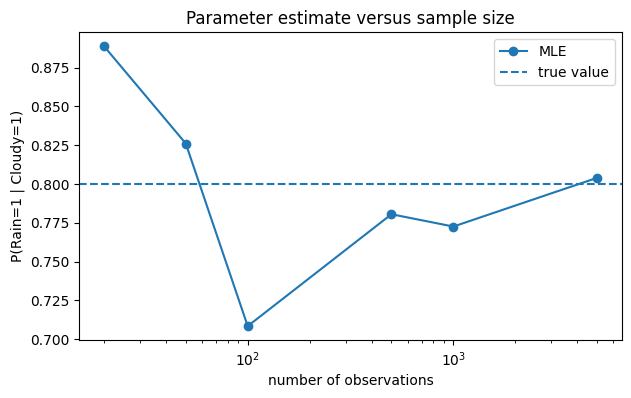

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, estimates, marker="o", label="MLE")
plt.axhline(0.8, linestyle="--", label="true value")
plt.xscale("log")
plt.xlabel("number of observations")
plt.ylabel("P(Rain=1 | Cloudy=1)")
plt.title("Parameter estimate versus sample size")
plt.legend()
plt.show()

### Ask the LLM to write the parameter-estimation code

Now the engineering task changes.

The LLM receives:

- the known graph structure;
- the fact that a `pandas.DataFrame` called `data` already exists;
- the requirement to estimate CPTs by maximum likelihood.

Again, the statistical estimator is implemented by `pgmpy`. The LLM's role is to construct the correct program.

In [24]:
estimation_prompt = r"""
Write Python code using the current pgmpy API.

A pandas DataFrame named data already exists. Its columns are:
Cloudy, Rain, Sprinkler, WetGrass.
All variables use binary states 0 and 1.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

The CPT parameters are unknown.

Requirements:
- use DiscreteBayesianNetwork;
- use MaximumLikelihoodEstimator;
- estimate all CPTs from data while keeping the graph fixed;
- store the fitted model in a variable called generated_mle_model;
- call generated_mle_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_estimation_response = ask_coder(estimation_prompt)
print(llm_estimation_response)

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


```python
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator

# Define the Bayesian Network structure
model = BayesianModel([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Create a list of tuples for each CPD
cpds = [
    (TabularCPD('Cloudy', 2, [[0.5], [0.5]])),
    (TabularCPD('Rain', 2, [[0.4, 0.6], [0.6, 0.4]])),
    (TabularCPD('Sprinkler', 2, [[0.7, 0.3], [0.3, 0.7]])),
    (TabularCPD('WetGrass', 2, [[0.9, 0.1], [0.1, 0.9]]))
]

# Add the CPDs to the model
for cpd in cpds:
    model.add_cpds(cpd)

# Use Maximum Likelihood Estimation to estimate the CPDs
mle = MaximumLikelihoodEstimator(model, data)
generated_mle_model = mle.estimate()

# Check if the model is valid
generated_mle_model.check_model()
```

This code snippet creates a Bayesian network based on the given structure and uses Maximum Likelihood Estimation to estimate the condition

In [25]:
generated_estimation_code = extract_python_code(llm_estimation_response)
print(generated_estimation_code)

problems = basic_generated_code_check(generated_estimation_code)
print("\nBasic check:", problems if problems else "no listed problems")

from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator

# Define the Bayesian Network structure
model = BayesianModel([('Cloudy', 'Rain'), ('Cloudy', 'Sprinkler'), ('Rain', 'WetGrass'), ('Sprinkler', 'WetGrass')])

# Create a list of tuples for each CPD
cpds = [
    (TabularCPD('Cloudy', 2, [[0.5], [0.5]])),
    (TabularCPD('Rain', 2, [[0.4, 0.6], [0.6, 0.4]])),
    (TabularCPD('Sprinkler', 2, [[0.7, 0.3], [0.3, 0.7]])),
    (TabularCPD('WetGrass', 2, [[0.9, 0.1], [0.1, 0.9]]))
]

# Add the CPDs to the model
for cpd in cpds:
    model.add_cpds(cpd)

# Use Maximum Likelihood Estimation to estimate the CPDs
mle = MaximumLikelihoodEstimator(model, data)
generated_mle_model = mle.estimate()

# Check if the model is valid
generated_mle_model.check_model()

Basic check: no listed problems


**[Added] Inspection notes (estimation code):**

1. Uses the removed `BayesianModel` again, so the import will fail.
2. Before estimating, it adds hand-written CPDs with invented numbers (`[[0.4, 0.6], [0.6, 0.4]]` and so on) that have nothing to do with the data or the specification, and that lack `evidence`/`evidence_card`.
3. `MaximumLikelihoodEstimator(model, data).estimate()` is an older API. In any case, `estimate()` returns CPDs, not a fitted model, so `generated_mle_model.check_model()` would be wrong even if the import worked.

The request was simple ("fit the parameters of a fixed graph"), but the code mixes specification and estimation. That makes it a semantic error as well as an API error.

#### Execute only after inspection

The generated code should use the provided DataFrame rather than inventing new data.

In [26]:
APPROVE_ESTIMATION_CODE = True  # approved after inspection (see notes above)

generated_estimation_namespace = {
    "data": data_1000.copy(),
}

if APPROVE_ESTIMATION_CODE:
    problems = basic_generated_code_check(generated_estimation_code)

    if problems:
        raise RuntimeError(f"Generated code did not pass basic checks: {problems}")

    try:
        exec(generated_estimation_code, generated_estimation_namespace)
        print("Generated estimation code executed.")
    except Exception as err:
        print("Generated code FAILED:", type(err).__name__ + ":", err)
else:
    print("Generated code NOT executed. Inspect it first, then approve it.")

Generated code FAILED: ImportError: cannot import name 'BayesianModel' from 'pgmpy.models' (.../site-packages/pgmpy/models/__init__.py)


#### Compare the LLM-generated fitted model with the trusted fit

For the same data and the same maximum-likelihood estimator, the fitted CPTs should agree numerically.

In [27]:
def cpd_value_map(model):
    """Flatten CPD arrays into a dictionary for easy numerical comparison."""
    result = {}

    for cpd in model.get_cpds():
        result[cpd.variable] = np.asarray(cpd.values, dtype=float)

    return result


def compare_models(model_a, model_b):
    a = cpd_value_map(model_a)
    b = cpd_value_map(model_b)

    variables = sorted(a)
    rows = []

    for variable in variables:
        diff = np.max(np.abs(a[variable] - b[variable]))
        rows.append({
            "variable": variable,
            "max absolute difference": diff,
        })

    return pd.DataFrame(rows)


if APPROVE_ESTIMATION_CODE and "generated_mle_model" not in generated_estimation_namespace:
    print("No generated_mle_model to compare: the generated code failed (see above).")
elif APPROVE_ESTIMATION_CODE:
    generated_mle_model = generated_estimation_namespace["generated_mle_model"]

    assert generated_mle_model.check_model()
    display(compare_models(mle_model_1000, generated_mle_model))
else:
    print("Run after approving the LLM-generated estimation code.")

No generated_mle_model to compare: the generated code failed (see above).


#### [Added] Revised estimation prompt

The same lesson applies: state the API of the installed version explicitly and forbid hand-written CPDs.

In [28]:
EST_API_RULES = r"""
API rules (pgmpy 1.x). Follow them exactly:
- BayesianModel no longer exists. Do not use it.
- Imports: from pgmpy.models import DiscreteBayesianNetwork; from pgmpy.parameter_estimator import DiscreteMLE, DiscreteBayesianEstimator
- Build the graph with DiscreteBayesianNetwork([("Cloudy", "Rain"), ...]). Do not add any TabularCPD by hand.
- Fit parameters with model.fit(data, estimator=DiscreteMLE()) for maximum likelihood, or
  model.fit(data, estimator=DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=10)) for Bayesian estimation.
- Use the existing DataFrame called data. Do not load, create, or modify data.
"""

EST_HEAD = """A pandas DataFrame named data already exists with binary columns:
Cloudy, Rain, Sprinkler, WetGrass (states 0 and 1).

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass
"""

def est_requirements(task, var):
    return f"""
Requirements:
- {task}, keeping the graph fixed;
- store the fitted model in a variable called {var};
- call {var}.check_model();
- do not install packages, read or write files, or use network access;
- return only Python code.
"""

mle_code_v2 = extract_python_code(ask_coder(EST_HEAD + EST_API_RULES + est_requirements("estimate all CPTs by maximum likelihood", "generated_mle_model")))
print(mle_code_v2)
ns_mle, status = exec_generated(mle_code_v2, {"data": data_1000.copy()})
print("\nexecution:", status)
generated_mle_model = ns_mle["generated_mle_model"]
assert generated_mle_model.check_model()
mle_diff = compare_models(mle_model_1000, generated_mle_model)
display(mle_diff)
assert mle_diff["max absolute difference"].max() == 0.0
print("Revised LLM estimation code reproduces the trusted MLE fit exactly.")

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE

# Define the Bayesian network structure
bn = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
    ("Cloudy", "Sprinkler"),
    ("Rain", "WetGrass"),
    ("Sprinkler", "WetGrass")
])

# Fit the model using maximum likelihood
generated_mle_model = bn.fit(data, estimator=DiscreteMLE())

# Check the model
generated_mle_model.check_model()

execution: ran


,variable,max absolute difference
0,Cloudy,0.0
1,Rain,0.0
2,Sprinkler,0.0
3,WetGrass,0.0


Revised LLM estimation code reproduces the trusted MLE fit exactly.


### Sparse data and Bayesian parameter estimation

Maximum likelihood uses the observed counts directly.

With a small dataset, some parent-state configurations can be rare or even absent. This can produce unstable estimates or probabilities equal to 0 or 1 simply because the sample is small.

A Bayesian estimator adds prior pseudo-counts.

For a Dirichlet prior, the posterior parameter estimate can be viewed conceptually as

$$
\text{posterior counts}
=
\text{observed counts}
+
\text{prior pseudo-counts}.
$$

This is not a claim that one estimator is always better. It is a different modelling assumption that can regularise estimates when data are sparse.

In [29]:
from pgmpy.parameter_estimator import (
    DiscreteMLE,
    DiscreteBayesianEstimator,
)

data_small = reference_model.simulate(
    n_samples=30,
    seed=11,
    show_progress=False,
)

mle_small = make_empty_structure()
mle_small.fit(
    data_small,
    estimator=DiscreteMLE(),
)

bayes_small = make_empty_structure()
bayes_small.fit(
    data_small,
    estimator=DiscreteBayesianEstimator(
        prior_type="BDeu",
        equivalent_sample_size=10,
    ),
)

print("MLE Rain CPD")
print(mle_small.get_cpds("Rain"))

print("\nBayesian Rain CPD")
print(bayes_small.get_cpds("Rain"))

MLE Rain CPD
+---------+---------------------+---------------------+
| Cloudy  | Cloudy(0)           | Cloudy(1)           |
+---------+---------------------+---------------------+
| Rain(0) | 0.9473684210526315  | 0.09090909090909091 |
+---------+---------------------+---------------------+
| Rain(1) | 0.05263157894736842 | 0.9090909090909091  |
+---------+---------------------+---------------------+

Bayesian Rain CPD
+---------+---------------------+-----------+
| Cloudy  | Cloudy(0)           | Cloudy(1) |
+---------+---------------------+-----------+
| Rain(0) | 0.8541666666666666  | 0.21875   |
+---------+---------------------+-----------+
| Rain(1) | 0.14583333333333334 | 0.78125   |
+---------+---------------------+-----------+


#### Compare the small-sample estimates

The BDeu estimate incorporates a prior equivalent sample size.

We should interpret the difference scientifically:

- MLE reflects the empirical frequencies directly;
- Bayesian estimation combines data with the specified prior.

The prior is part of the model and should not be hidden as an implementation detail.

In [30]:
def rain_c1_probability(model):
    return float(model.get_cpds("Rain").values[1, 1])

comparison = pd.DataFrame({
    "method": ["True parameter", "MLE, N=30", "BDeu, N=30"],
    "P(Rain=1 | Cloudy=1)": [
        0.8,
        rain_c1_probability(mle_small),
        rain_c1_probability(bayes_small),
    ],
})

comparison

,method,P(Rain=1 | Cloudy=1)
0,True parameter,0.800000
1,"MLE, N=30",0.909091
2,"BDeu, N=30",0.781250


### Ask the LLM to revise MLE code to Bayesian estimation

This is a useful coding-assistant task because we already know the desired statistical change.

The LLM is asked to revise the implementation, while we remain responsible for checking whether the generated code actually uses the requested prior.

In [31]:
bayesian_prompt = r"""
A pandas DataFrame named data already exists with binary columns:
Cloudy, Rain, Sprinkler, WetGrass.

The known Bayesian-network structure is:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Write Python code using the current pgmpy API to estimate all CPTs with BayesianEstimator.
Use:
prior_type="BDeu"
equivalent_sample_size=10

Requirements:
- keep the graph fixed;
- store the fitted model in generated_bayes_model;
- call generated_bayes_model.check_model();
- do not install packages;
- do not read or write files;
- do not use network access;
- return only Python code.
"""

llm_bayesian_response = ask_coder(bayesian_prompt)
print(llm_bayesian_response)

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


```python
from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load the data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model()
```

This code snippet loads the data from a CSV file, creates a BayesianEstimator object with the specified prior type and equivalent sample size, fits the model to the data, checks the model for validity, and stores the fitted model in `generated_bayes_model`.


In [32]:
generated_bayesian_code = extract_python_code(llm_bayesian_response)
print(generated_bayesian_code)

problems = basic_generated_code_check(generated_bayesian_code)
print("\nBasic check:", problems if problems else "no listed problems")

from pgmpy.estimators import BayesianEstimator
import pandas as pd

# Load the data into a pandas DataFrame
data = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your actual file path

# Create a BayesianEstimator object
estimator = BayesianEstimator(data, ['Cloudy', 'Rain', 'Sprinkler', 'WetGrass'])

# Fit the model with BDeu prior and equivalent sample size of 10
generated_bayes_model = estimator.fit(prior_type="BDeu", equivalent_sample_size=10)

# Check if the model is valid
generated_bayes_model.check_model()

Basic check: no listed problems


**[Added] Inspection notes (Bayesian estimation code):**

1. **It reads a file:** `data = pd.read_csv('your_data.csv')`. The prompt explicitly said *do not read or write files*, and said that `data` already exists. Even if the file existed, this line would silently replace our dataset with a different one.
2. `BayesianEstimator(data, [...])` passes a list of column names where a *model* is expected, so the graph structure is never given. The requested fixed graph is lost.
3. `estimator.fit(...)` is not a method of that estimator.

The basic static check reports **no problems** for this code, because it only looks for calls to the bare name `open(...)`, not for `pd.read_csv(...)`.

**[Added] The static check has a gap.** It flags `open(...)` but not attribute calls such as `pd.read_csv(...)` or `os.system(...)`. File and network access through a library method passes silently. I extended the check below. From here on, all generated code goes through the extended version, which rejects the Bayesian-estimation code *before* it runs. This is still not a sandbox, only a better filter.

In [33]:
# [Added] Extend the static check: flag file and network I/O done through attribute calls too.
FORBIDDEN_ATTRIBUTE_CALLS = {"read_csv", "read_excel", "read_json", "read_parquet", "read_pickle",
                             "to_csv", "to_excel", "to_pickle", "urlopen", "system", "popen"}
_basic_check_v1 = basic_generated_code_check

def basic_generated_code_check(source):
    problems = _basic_check_v1(source)
    for node in ast.walk(ast.parse(source)):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute) and node.func.attr in FORBIDDEN_ATTRIBUTE_CALLS:
            problems.append(f"Forbidden call: .{node.func.attr}()")
    return problems

print("original check :", _basic_check_v1(generated_bayesian_code) or "no listed problems")
print("extended check :", basic_generated_code_check(generated_bayesian_code))

original check : no listed problems
extended check : ['Forbidden call: .read_csv()']


#### [Added] Execute and validate the Bayesian-estimation code

The original notebook generated this code but never ran it. Here it is executed on the same `data_small` (N = 30) used for `bayes_small`, and compared entry by entry with the trusted fit. If the generated code really uses BDeu with an equivalent sample size of 10, every difference should be 0. As a second check, it should *not* match the MLE fit.

In [34]:
APPROVE_BAYES_CODE = True  # approved after inspection (see notes above)

generated_bayes_namespace = {"data": data_small.copy()}

if APPROVE_BAYES_CODE:
    problems = basic_generated_code_check(generated_bayesian_code)
    if problems:
        print("Generated code REJECTED before execution:", problems)
    else:
        try:
            exec(generated_bayesian_code, generated_bayes_namespace)
        except Exception as err:
            print("Generated code FAILED:", type(err).__name__ + ":", err)
if "generated_bayes_model" in generated_bayes_namespace:
    generated_bayes_model = generated_bayes_namespace["generated_bayes_model"]
    assert generated_bayes_model.check_model()
    print("vs trusted BDeu fit:")
    display(compare_models(bayes_small, generated_bayes_model))
    print("vs MLE fit (should differ):")
    display(compare_models(mle_small, generated_bayes_model))

Generated code REJECTED before execution: ['Forbidden call: .read_csv()']


In [35]:
# [Added] Revised Bayesian-estimation prompt (same API rules as above)
bayes_code_v2 = extract_python_code(ask_coder(EST_HEAD + EST_API_RULES + est_requirements(
    'estimate all CPTs by Bayesian estimation with prior_type="BDeu" and equivalent_sample_size=10', "generated_bayes_model")))
print(bayes_code_v2)
ns_bayes, status = exec_generated(bayes_code_v2, {"data": data_small.copy()})
print("\nexecution:", status)
generated_bayes_model = ns_bayes["generated_bayes_model"]
assert generated_bayes_model.check_model()
print("vs trusted BDeu fit:")
bayes_diff = compare_models(bayes_small, generated_bayes_model)
display(bayes_diff)
print("vs MLE fit (must differ, otherwise the prior was ignored):")
display(compare_models(mle_small, generated_bayes_model))
assert bayes_diff["max absolute difference"].max() < 1e-12
assert compare_models(mle_small, generated_bayes_model)["max absolute difference"].max() > 0.01
print("Revised code uses the requested BDeu prior.")

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

# Define the Bayesian network structure
bn = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
    ("Cloudy", "Sprinkler"),
    ("Rain", "WetGrass"),
    ("Sprinkler", "WetGrass")
])

# Fit parameters using Bayesian estimation
generated_bayes_model = bn.fit(data, estimator=DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=10))

# Check the model
generated_bayes_model.check_model()

execution: ran
vs trusted BDeu fit:


,variable,max absolute difference
0,Cloudy,0.0
1,Rain,0.0
2,Sprinkler,0.0
3,WetGrass,0.0


vs MLE fit (must differ, otherwise the prior was ignored):


,variable,max absolute difference
0,Cloudy,0.033333
1,Rain,0.127841
2,Sprinkler,0.156250
3,WetGrass,0.357143


Revised code uses the requested BDeu prior.


### A deliberately broken Bayesian network

Validation matters even without an LLM.

Here we intentionally create an invalid CPT whose columns do not sum to 1.

The library should reject the model rather than silently using it.

In [36]:
broken_model = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
])

cpd_cloudy_ok = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
)

# Invalid: for Cloudy=0, 0.9 + 0.3 = 1.2.
cpd_rain_broken = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[
        [0.9, 0.2],
        [0.3, 0.8],
    ],
    evidence=["Cloudy"],
    evidence_card=[2],
)

broken_model.add_cpds(cpd_cloudy_ok, cpd_rain_broken)

try:
    broken_model.check_model()
except Exception as error:
    print("Validation caught the problem:")
    print(type(error).__name__ + ":", error)

Validation caught the problem:
ValueError: Sum or integral of conditional probabilities for node Rain is not equal to 1.


### A subtler failure: valid numbers, wrong semantics

Some mistakes are harder.

Imagine the four WetGrass probabilities are supplied in the wrong parent-state order.

Every column can still sum to 1, so `check_model()` may accept the CPD. Yet the model can represent the wrong distribution.

This is why we also need semantic tests such as known queries or independently calculated probabilities.

In [37]:
wrong_semantics_model = build_reference_model()

# Remove the correct WetGrass CPD.
wrong_semantics_model.remove_cpds(
    wrong_semantics_model.get_cpds("WetGrass")
)

# Deliberately permute the probabilities for the parent configurations.
wrong_wetgrass = TabularCPD(
    variable="WetGrass",
    variable_card=2,
    values=[
        [0.99, 0.10, 0.01, 0.10],
        [0.01, 0.90, 0.99, 0.90],
    ],
    evidence=["Rain", "Sprinkler"],
    evidence_card=[2, 2],
)

wrong_semantics_model.add_cpds(wrong_wetgrass)

print("check_model():", wrong_semantics_model.check_model())

wrong_inference = VariableElimination(wrong_semantics_model)
wrong_posterior = wrong_inference.query(
    ["Rain"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

print("Correct posterior:", posterior_rain.values[1])
print("Wrong posterior  :", wrong_posterior.values[1])

check_model(): True
Correct posterior: 0.7047692307692307
Wrong posterior  : 0.7172952268709487


**This is the central science-engineering lesson:**

```text
Program runs
    !=
Probabilistic model is correct
    !=
Scientific assumptions are appropriate
```

The LLM can accelerate implementation, but it does not remove the need to understand the model.

### Turn validation into reusable tests

Instead of checking things manually every time, encode important expectations as tests.

In [38]:
def test_reference_model():
    model = build_reference_model()

    assert model.check_model()

    assert set(model.nodes()) == {
        "Cloudy", "Rain", "Sprinkler", "WetGrass"
    }

    assert set(model.edges()) == {
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "WetGrass"),
        ("Sprinkler", "WetGrass"),
    }

    infer = VariableElimination(model)
    posterior = infer.query(
        ["Rain"],
        evidence={"WetGrass": 1},
        show_progress=False,
    )

    assert np.isclose(
        posterior.values[1],
        posterior_by_enumeration,
        atol=1e-10,
    )


test_reference_model()
print("All reference tests passed.")

All reference tests passed.


### What exactly did the LLM contribute?

The notebook contains several different computational roles.

| Task | Component responsible |
|---|---|
| Interpret the natural-language programming request | LLM |
| Generate candidate Python code | LLM |
| Represent the Bayesian network | `pgmpy` |
| Check local BN consistency | `pgmpy.check_model()` |
| Perform exact inference | `VariableElimination` |
| Estimate CPTs from data | `MaximumLikelihoodEstimator` / `BayesianEstimator` |
| Decide whether generated code is acceptable | validation logic + human |
| Decide whether the statistical assumptions make sense | human / scientific reasoning |

This separation is important.

An LLM coding assistant can be useful without being treated as the source of probabilistic truth.

### An engineering view of the whole notebook

The complete loop is

```text
Bayesian-network theory
        |
        v
Natural-language specification
        |
        v
      LLM
        |
        v
Generated Python code
        |
        v
Static inspection / approval
        |
        v
      pgmpy
        |
        v
Inference or parameter estimation
        |
        v
Validation against mathematical expectations
        |
        +---- pass ----> use result
        |
        +---- fail ----> revise specification/code
```

The important point is that AI engineering does not mean abandoning the scientific model.

It means building a dependable software process around it.

### HW exercise: change the query

Without changing the network, ask the LLM to generate code for each query:

$$
P(S=1\mid W=1),
$$

$$
P(C=1\mid W=1),
$$

and

$$
P(R=1\mid W=1,S=0).
$$

Before running the generated code:

- identify the query variable;
- identify the evidence;
- predict qualitatively whether the posterior should increase or decrease;
- inspect the generated code;
- compare it with a trusted `VariableElimination` call.

In [39]:
# Trusted query examples for the exercise.
trusted_infer = VariableElimination(reference_model)

q_s = trusted_infer.query(
    ["Sprinkler"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

q_c = trusted_infer.query(
    ["Cloudy"],
    evidence={"WetGrass": 1},
    show_progress=False,
)

q_r_given_w_s0 = trusted_infer.query(
    ["Rain"],
    evidence={"WetGrass": 1, "Sprinkler": 0},
    show_progress=False,
)

print("P(Sprinkler=1 | WetGrass=1) =", q_s.values[1])
print("P(Cloudy=1 | WetGrass=1) =", q_c.values[1])
print("P(Rain=1 | WetGrass=1, Sprinkler=0) =", q_r_given_w_s0.values[1])

P(Sprinkler=1 | WetGrass=1) = 0.4278461538461539
P(Cloudy=1 | WetGrass=1) = 0.5746153846153845
P(Rain=1 | WetGrass=1, Sprinkler=0) = 0.9922022048937886


### [Added] HW exercise, completed

**Before running anything:**

| Query | Query variable | Evidence | Prior | Prediction |
|---|---|---|---|---|
| P(S=1 given W=1) | Sprinkler | WetGrass=1 | P(S=1) = 0.5(0.5) + 0.5(0.1) = 0.30 | **increases**: the sprinkler is one of the two causes of wet grass, so observing the effect raises belief in each cause |
| P(C=1 given W=1) | Cloudy | WetGrass=1 | P(C=1) = 0.50 | **increases slightly**: wet grass points to rain, which is more likely when cloudy. But it also points to the sprinkler, which is *less* likely when cloudy, so the two effects partly cancel |
| P(R=1 given W=1, S=0) | Rain | WetGrass=1, Sprinkler=0 | P(R=1 given W=1) = 0.705 | **increases towards 1**: with the sprinkler ruled out, rain is almost the only remaining explanation (P(W=1 given R=0, S=0) is just 0.01). This is the flip side of explaining away |

A general-purpose enumeration oracle (below) generalises the notebook's 16-assignment check to any query and evidence.

In [40]:
VARS = ["Cloudy", "Rain", "Sprinkler", "WetGrass"]

def joint(c, r, s, w):
    return p_cloudy(c) * p_rain(r, c) * p_sprinkler(s, c) * p_wetgrass(w, r, s)

def enumerate_posterior(query, evidence):
    """P(query=1 | evidence) by summing the full joint over all 16 assignments."""
    num = den = 0.0
    for values in itertools.product([0, 1], repeat=4):
        a = dict(zip(VARS, values))
        if any(a[k] != v for k, v in evidence.items()):
            continue
        p = joint(a["Cloudy"], a["Rain"], a["Sprinkler"], a["WetGrass"])
        den += p
        if a[query] == 1:
            num += p
    return num / den

queries = {
    "q_s": ("Sprinkler", {"WetGrass": 1}),
    "q_c": ("Cloudy", {"WetGrass": 1}),
    "q_r_given_w_s0": ("Rain", {"WetGrass": 1, "Sprinkler": 0}),
}
priors = {"q_s": 0.30, "q_c": 0.50, "q_r_given_w_s0": float(posterior_rain.values[1])}
trusted_values = {"q_s": q_s.values[1], "q_c": q_c.values[1], "q_r_given_w_s0": q_r_given_w_s0.values[1]}

rows = []
for name, (var, ev) in queries.items():
    rows.append({
        "query": f"P({var}=1 | {ev})",
        "before evidence": priors[name],
        "trusted VE": trusted_values[name],
        "enumeration": enumerate_posterior(var, ev),
        "direction": "up" if trusted_values[name] > priors[name] else "down",
    })
hw_table = pd.DataFrame(rows)
hw_table

,query,before evidence,trusted VE,enumeration,direction
0,P(Sprinkler=1 | {'WetGrass': 1}),0.300000,0.427846,0.427846,up
1,P(Cloudy=1 | {'WetGrass': 1}),0.500000,0.574615,0.574615,up
2,"P(Rain=1 | {'WetGrass': 1, 'Sprinkler': 0})",0.704769,0.992202,0.992202,up


#### [Added] Ask the LLM for each query

Each prompt gives the full network specification (the model is not allowed to assume anything), and names the query and the evidence.

In [41]:
BN_SPEC = r"""
Construct this binary discrete Bayesian network with the current pgmpy API
(DiscreteBayesianNetwork, TabularCPD, VariableElimination).

Edges:
Cloudy -> Rain
Cloudy -> Sprinkler
Rain -> WetGrass
Sprinkler -> WetGrass

Use states 0=False and 1=True.

Probabilities:
P(Cloudy=1) = 0.5
P(Rain=1 | Cloudy=0) = 0.2
P(Rain=1 | Cloudy=1) = 0.8
P(Sprinkler=1 | Cloudy=0) = 0.5
P(Sprinkler=1 | Cloudy=1) = 0.1
P(WetGrass=1 | Rain=0, Sprinkler=0) = 0.01
P(WetGrass=1 | Rain=0, Sprinkler=1) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=0) = 0.90
P(WetGrass=1 | Rain=1, Sprinkler=1) = 0.99
"""

query_text = {
    "q_s": "compute P(Sprinkler | WetGrass=1)",
    "q_c": "compute P(Cloudy | WetGrass=1)",
    "q_r_given_w_s0": "compute P(Rain | WetGrass=1, Sprinkler=0)",
}

generated_query_code = {}
for name, text in query_text.items():
    prompt = BN_SPEC + f"""
Requirements:
- create the model in a variable called generated_model and call generated_model.check_model();
- use VariableElimination to {text};
- store the query result (the DiscreteFactor returned by query) in a variable called {name};
- do not install packages, read or write files, or use network access;
- return only Python code.
"""
    response = ask_coder(prompt)
    generated_query_code[name] = extract_python_code(response)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(generated_query_code[name])
    print("Basic check:", basic_generated_code_check(generated_query_code[name]) or "no listed problems")

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


q_s
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD

# Create the Bayesian Network
generated_model = BayesianModel()

# Define the variables
cloudy = Variable('Cloudy', 2)
rain = Variable('Rain', 2)
sprinkler = Variable('Sprinkler', 2)
wet_grass = Variable('WetGrass', 2)

# Add edges
generated_model.add_edge(cloudy, rain)
generated_model.add_edge(cloudy, sprinkler)
generated_model.add_edge(rain, wet_grass)
generated_model.add_edge(sprinkler, wet_grass)

# Define CPDs
cpd_cloudy = TabularCPD(cloudy, [1], [[0.5], [0.5]])
cpd_rain_given_cloudy = TabularCPD(rain, [1, 1], [[0.2, 0.8], [0.5, 0.1]], evidence=[cloudy])
cpd_sprinkler_given_cloudy = TabularCPD(sprinkler, [1, 1], [[0.5, 0.1], [0.5, 0.9]], evidence=[cloudy])
cpd_wet_grass_given_rain_and_sprinkler = TabularCPD(wet_grass, [1, 1, 1], [
    [0.01, 0.90, 0.90],
    [0.90, 0.01, 0.90],
    [0.90, 0.90, 0.01],
    [0.99, 0.99, 0.99]
], evidence=[rain, sprinkler])

# Add CPDs to the model
generated_mod

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


q_c
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD

# Create the Bayesian Network
generated_model = BayesianModel()

# Define the variables
cloudy = 'Cloudy'
rain = 'Rain'
sprinkler = 'Sprinkler'
wet_grass = 'WetGrass'

# Add nodes to the model
generated_model.add_nodes_from([cloudy, rain, sprinkler, wet_grass])

# Define the CPDs for each variable
cpd_cloudy = TabularCPD(cloudy, [1], [[0.5]])
cpd_rain_given_cloudy = TabularCPD(rain, [1, 1], [[0.2, 0.8], [0.5, 0.1]], evidence=[cloudy])
cpd_sprinkler_given_cloudy = TabularCPD(sprinkler, [1, 1], [[0.5, 0.1], [0.5, 0.9]], evidence=[cloudy])
cpd_wet_grass_given_rain_and_sprinkler = TabularCPD(wet_grass, [1, 1, 1], [
    [0.01, 0.90, 0.90],
    [0.90, 0.01, 0.90],
    [0.90, 0.90, 0.01]
], evidence=[rain, sprinkler])

# Add the CPDs to the model
generated_model.add_cpds(cpd_cloudy, cpd_rain_given_cloudy, cpd_sprinkler_given_cloudy, cpd_wet_grass_given_rain_and_sprinkler)

# Check the model
generated_mod

q_r_given_w_s0
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD

# Create the Bayesian Network
generated_model = BayesianModel()

# Define the variables
cloudy = generated_model.add_node('Cloudy')
rain = generated_model.add_node('Rain')
sprinkler = generated_model.add_node('Sprinkler')
wet_grass = generated_model.add_node('WetGrass')

# Add edges
generated_model.add_edge(cloudy, rain)
generated_model.add_edge(cloudy, sprinkler)
generated_model.add_edge(rain, wet_grass)
generated_model.add_edge(sprinkler, wet_grass)

# Define the CPDs
cpd_cloudy = TabularCPD(
    'Cloudy', 2, [0.5, 0.5], evidence=None, state_names={'Cloudy': [0, 1]})
cpd_rain_given_cloudy = TabularCPD(
    'Rain', 2, [[0.2, 0.8], [0.8, 0.2]], evidence=['Cloudy'], state_names={'Rain': [0, 1]})
cpd_sprinkler_given_cloudy = TabularCPD(
    'Sprinkler', 2, [[0.5, 0.1], [0.1, 0.5]], evidence=['Cloudy'], state_names={'Sprinkler': [0, 1]})
cpd_wet_grass_given_rain_and_sprinkler = TabularCPD(

**[Added] Inspection notes (round A query code):** all three programs import the removed `BayesianModel` again. The ones shown above also call `model.query` instead of using `VariableElimination`, and build CPDs with the wrong shapes. The `q_s` code also uses an undefined `Variable` class. The WetGrass CPTs have 3 columns in 3 or 4 rows, with the specified numbers scattered in the wrong places. Mentioning `DiscreteBayesianNetwork` in the prompt header was not enough. I expect all three to fail on import.

In [42]:
APPROVE_QUERY_CODE = True  # approved after inspection (see notes above)

hw_rows = []
if APPROVE_QUERY_CODE:
    for name, (var, ev) in queries.items():
        ns = {}
        problems = basic_generated_code_check(generated_query_code[name])
        if problems:
            raise RuntimeError(f"{name}: generated code did not pass basic checks: {problems}")
        try:
            exec(generated_query_code[name], ns)
            factor = ns[name]
            # check the factor is over the right variable before trusting values[1]
            assert factor.variables == [var], f"query variable is {factor.variables}, expected {[var]}"
            value = float(factor.values[1])
            status = "ran"
        except Exception as err:
            value, status = float("nan"), f"{type(err).__name__}: {err}"
        hw_rows.append({
            "query": name,
            "LLM code": value,
            "trusted VE": float(trusted_values[name]),
            "enumeration": enumerate_posterior(var, ev),
            "abs error vs trusted": abs(value - float(trusted_values[name])),
            "status": status,
        })
hw_results = pd.DataFrame(hw_rows)
hw_results

,query,LLM code,trusted VE,enumeration,abs error vs trusted,status
0,q_s,NaN,0.427846,0.427846,NaN,ImportError: cannot import name 'BayesianModel...
1,q_c,NaN,0.574615,0.574615,NaN,ImportError: cannot import name 'BayesianModel...
2,q_r_given_w_s0,NaN,0.992202,0.992202,NaN,ImportError: cannot import name 'BayesianModel...


**[Added] Round A result:** as predicted, all three fail with `ImportError: cannot import name 'BayesianModel'`, so no posterior is produced.

#### [Added] Round B: the prompt that worked for the inference code

The same three queries, now asked with the explicit CPT tables and API rules from the revision above. The same one-line `human_fix` is applied, and the diff is printed so every manual change is visible.

In [43]:
hw_rows_v2 = []
for name, (var, ev) in queries.items():
    source = extract_python_code(ask_coder(CPT_TABLES + API_RULES + query_requirements(query_text[name].replace("compute ", "compute "), name)))
    fixed = human_fix(source)
    print("=" * 70); print(name); print("=" * 70)
    print(source)
    print("--- human edit:")
    show_diff(source, fixed)
    ns, status = exec_generated(fixed)
    value = float("nan")
    if name in ns:
        factor = ns[name]
        assert factor.variables == [var], f"query variable is {factor.variables}, expected {[var]}"
        value = float(factor.values[1])
    hw_rows_v2.append({
        "query": name,
        "LLM code (after edit)": value,
        "trusted VE": float(trusted_values[name]),
        "enumeration": enumerate_posterior(var, ev),
        "abs error vs trusted": abs(value - float(trusted_values[name])),
        "status": status,
        "manual edits": fixed != source,
    })
hw_results_v2 = pd.DataFrame(hw_rows_v2)
hw_results_v2

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


q_s
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
    ("Cloudy", "Sprinkler"),
    ("Rain", "WetGrass"),
    ("Sprinkler", "WetGrass")
])

# Define the CPDs
cloudy_cpd = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
    evidence=None,
    evidence_card=None
)

rain_cpd = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[[0.8, 0.2], [0.2, 0.8]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

sprinkler_cpd = TabularCPD(
    variable="Sprinkler",
    variable_card=2,
    values=[[0.5, 0.9], [0.5, 0.1]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

wet_grass_cpd = TabularCPD(
    variable="WetGrass",
    variable_card=4,
    values=[[0.99, 0.10, 0.10, 0.01],
             [0.01, 0.90, 0.90, 0.99]],
    evidence=["Rain", "Sprinkler"],
    

[transformers] Both `max_new_tokens` (=1400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


q_c
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
    ("Cloudy", "Sprinkler"),
    ("Rain", "WetGrass"),
    ("Sprinkler", "WetGrass")
])

# Define the CPDs
cloudy_cpd = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
    evidence=None,
    evidence_card=None
)

rain_cpd = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[[0.8, 0.2], [0.2, 0.8]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

sprinkler_cpd = TabularCPD(
    variable="Sprinkler",
    variable_card=2,
    values=[[0.5, 0.9], [0.5, 0.1]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

wet_grass_cpd = TabularCPD(
    variable="WetGrass",
    variable_card=4,
    values=[[0.99, 0.10, 0.10, 0.01],
             [0.01, 0.90, 0.90, 0.99]],
    evidence=["Rain", "Sprinkler"],
    

q_r_given_w_s0
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Create the Bayesian Network
generated_model = DiscreteBayesianNetwork([
    ("Cloudy", "Rain"),
    ("Cloudy", "Sprinkler"),
    ("Rain", "WetGrass"),
    ("Sprinkler", "WetGrass")
])

# Define the CPDs
cloudy_cpd = TabularCPD(
    variable="Cloudy",
    variable_card=2,
    values=[[0.5], [0.5]],
    evidence=None,
    evidence_card=None
)

rain_cpd = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[[0.8, 0.2], [0.2, 0.8]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

sprinkler_cpd = TabularCPD(
    variable="Sprinkler",
    variable_card=2,
    values=[[0.5, 0.9], [0.5, 0.1]],
    evidence=["Cloudy"],
    evidence_card=[2]
)

wet_grass_cpd = TabularCPD(
    variable="WetGrass",
    variable_card=4,
    values=[[0.99, 0.10, 0.10, 0.01],
             [0.01, 0.90, 0.90, 0.99]],
    evidence=["Rain", "Sprink

,query,LLM code (after edit),trusted VE,enumeration,abs error vs trusted,status,manual edits
0,q_s,0.427846,0.427846,0.427846,0.0,ran,True
1,q_c,0.574615,0.574615,0.574615,0.0,ran,True
2,q_r_given_w_s0,0.992202,0.992202,0.992202,0.0,ran,True


In [44]:
# [Added] assertions: every generated query must match the trusted result
for _, row in hw_results_v2.iterrows():
    assert np.isclose(row["trusted VE"], row["enumeration"], atol=1e-12)
    assert np.isclose(row["LLM code (after edit)"], row["trusted VE"], atol=1e-10), row["query"]
print("All three LLM-generated queries match VariableElimination and enumeration.")

All three LLM-generated queries match VariableElimination and enumeration.


**[Added] Discussion of the HW queries**

| query | before evidence | after evidence | predicted | observed |
|---|---|---|---|---|
| P(S=1 given W=1) | 0.300 | **0.4278** | up | up |
| P(C=1 given W=1) | 0.500 | **0.5746** | slightly up | slightly up |
| P(R=1 given W=1, S=0) | 0.7048 (P(R=1 given W=1)) | **0.9922** | up, towards 1 | up, to 0.99 |

All three predictions were right. The third is the most instructive. Wet grass alone makes rain 70% likely. Learning that the sprinkler was *off* removes the competing explanation, so rain becomes almost certain. Conversely, learning that the sprinkler was *on* would lower belief in rain: that is **explaining away**, and it happens because Rain and Sprinkler become dependent once their common effect WetGrass is observed. The Cloudy result is a small net increase, because the evidence flows back through two paths with opposite signs: rain is more likely when cloudy (+), and the sprinkler is less likely when cloudy (-).

Engineering result: with the revised prompt and the same single manual edit (`variable_card=4` to `2` in every program, shown in the diffs above), all three generated programs agree with `VariableElimination` and with full enumeration to within 1e-10. Each result was also checked to be a factor over the *correct* query variable before `values[1]` was read, since `values[1]` of the wrong factor would still be a plausible-looking number.

### Classroom exercise: let the LLM explain its generated CPT

Ask the LLM:

> Explain exactly what each column of the WetGrass `TabularCPD` represents when `evidence=["Rain", "Sprinkler"]`. Do not change the code.

Then verify the explanation against the actual library convention and against the probabilities we specified.

This is useful because code generation and code explanation are different tasks, and either can be wrong.

#### [Added] Classroom exercise: ask the LLM to explain the WetGrass CPT

In [45]:
wetgrass_cpd_code = '''
cpd_wetgrass = TabularCPD(
    variable="WetGrass",
    variable_card=2,
    values=[
        [0.99, 0.10, 0.10, 0.01],  # WetGrass=0
        [0.01, 0.90, 0.90, 0.99],  # WetGrass=1
    ],
    evidence=["Rain", "Sprinkler"],
    evidence_card=[2, 2],
)
'''

explain_prompt = (
    "Here is a pgmpy TabularCPD:\n" + wetgrass_cpd_code +
    "\nExplain exactly what each column of the WetGrass TabularCPD represents when "
    "evidence=[\"Rain\", \"Sprinkler\"]. For each of the four columns, give the Rain value, "
    "the Sprinkler value, and P(WetGrass=1) for that column. Do not change the code."
)
cpt_explanation = ask_coder(explain_prompt, max_new_tokens=600)
print(cpt_explanation)

[transformers] Both `max_new_tokens` (=600) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The first column of the WetGrass TabularCPD represents the probability of WetGrass being 0 given the evidence of Rain being 0 and Sprinkler being 0. The second column represents the probability of WetGrass being 0 given the evidence of Rain being 0 and Sprinkler being 1. The third column represents the probability of WetGrass being 0 given the evidence of Rain being 1 and Sprinkler being 0. The fourth column represents the probability of WetGrass being 0 given the evidence of Rain being 1 and Sprinkler being 1.

The probabilities in each column are as follows:
- WetGrass=0, Rain=0, Sprinkler=0: 0.99
- WetGrass=0, Rain=0, Sprinkler=1: 0.10
- WetGrass=0, Rain=1, Sprinkler=0: 0.01
- WetGrass=0, Rain=1, Sprinkler=1: 0.99

These probabilities represent the conditional probability of WetGrass being 0 given the specific combination of Rain and Sprinkler conditions.


In [46]:
# [Added] Verify against the actual library convention, not the LLM's word.
wg = reference_model.get_cpds("WetGrass")
print("pgmpy column order (state_names):", wg.state_names)
for col, (r, s) in enumerate(itertools.product([0, 1], repeat=2)):
    lib = wg.get_value(WetGrass=1, Rain=r, Sprinkler=s)
    print(f"column {col}: Rain={r}, Sprinkler={s} -> P(WetGrass=1) = {lib:.2f} (table value {wg.values[1, r, s]:.2f}, spec {p_wetgrass(1, r, s):.2f})")

pgmpy column order (state_names): {'WetGrass': [0, 1], 'Rain': [0, 1], 'Sprinkler': [0, 1]}
column 0: Rain=0, Sprinkler=0 -> P(WetGrass=1) = 0.01 (table value 0.01, spec 0.01)
column 1: Rain=0, Sprinkler=1 -> P(WetGrass=1) = 0.90 (table value 0.90, spec 0.90)
column 2: Rain=1, Sprinkler=0 -> P(WetGrass=1) = 0.90 (table value 0.90, spec 0.90)
column 3: Rain=1, Sprinkler=1 -> P(WetGrass=1) = 0.99 (table value 0.99, spec 0.99)


**[Added] Checking the explanation.** The LLM got the **parent configuration of each column right**: (Rain=0, Sprinkler=0), (Rain=0, Sprinkler=1), (Rain=1, Sprinkler=0), (Rain=1, Sprinkler=1), which matches pgmpy's convention (the last evidence variable varies fastest). But:

- I asked for P(WetGrass=1) per column. It answered with P(WetGrass=0) instead.
- Two of its four numbers are **wrong**. It says P(WetGrass=0 given Rain=1, Sprinkler=0) = 0.01 (the table says 0.10), and P(WetGrass=0 given Rain=1, Sprinkler=1) = 0.99 (the table says 0.01). It was reading from the wrong row.

The cell above, which uses `get_value` on the actual CPD, confirms that the correct values of P(WetGrass=1) are 0.01, 0.90, 0.90, 0.99. The explanation *sounds* authoritative, but it would have taught a student the wrong table. As the notebook says, code explanation is a separate task from code generation, and either can be wrong.

### Classroom exercise: estimate from different datasets

Generate several datasets using different random seeds.

For each one:

- fit an MLE model;
- record $\widehat{P}(R=1\mid C=1)$;
- compare it with the true value $0.8$;
- ask the LLM to explain why different datasets produce different estimates.

The correct scientific explanation should refer to **sampling variability**, not to the LLM or to `pgmpy` being inconsistent.

In [47]:
from pgmpy.parameter_estimator import DiscreteMLE

rows = []

for seed in [1, 2, 3, 4, 5]:
    data = reference_model.simulate(
        n_samples=100,
        seed=seed,
        show_progress=False,
    )

    fitted = make_empty_structure()

    fitted.fit(
        data,
        estimator=DiscreteMLE(),
    )

    rows.append({
        "seed": seed,
        "estimate": rain_c1_probability(fitted),
    })

pd.DataFrame(rows)

,seed,estimate
0,1,0.693878
1,2,0.795455
2,3,0.744681
3,4,0.767857
4,5,0.795918


In [48]:
# [Added] Is the spread across seeds what sampling variability predicts?
seed_estimates = pd.DataFrame(rows)["estimate"]
# P(Rain=1 | Cloudy=1) is estimated from the ~N/2 cloudy rows, so its standard error is
# sqrt(p(1-p)/n_cloudy) with n_cloudy ~ 50 for N=100.
predicted_se = np.sqrt(0.8 * 0.2 / 50)
print(f"mean of 5 estimates = {seed_estimates.mean():.4f}   (true 0.8)")
print(f"observed std        = {seed_estimates.std(ddof=1):.4f}")
print(f"predicted std error = {predicted_se:.4f}")

spread = []
for s in range(200):
    d = reference_model.simulate(n_samples=100, seed=1000 + s, show_progress=False)
    m = make_empty_structure()
    m.fit(d, estimator=DiscreteMLE())
    spread.append(rain_c1_probability(m))
spread = np.array(spread)
print(f"200 datasets: mean = {spread.mean():.4f}, std = {spread.std(ddof=1):.4f}")

mean of 5 estimates = 0.7596   (true 0.8)
observed std        = 0.0425
predicted std error = 0.0566


200 datasets: mean = 0.8057, std = 0.0552


In [49]:
datasets_prompt = (
    "I fitted a Bayesian network by maximum likelihood to five different datasets of 100 samples each, "
    "all generated from the same known model where P(Rain=1 | Cloudy=1) = 0.8. The estimates of "
    "P(Rain=1 | Cloudy=1) were: " + ", ".join(f"{v:.3f}" for v in seed_estimates) +
    ". In a short paragraph, explain why different datasets produce different estimates, and whether "
    "this indicates a bug in the estimation library."
)
datasets_explanation = ask_coder(datasets_prompt, max_new_tokens=400)
print(datasets_explanation)

[transformers] Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The differences in the estimated probabilities (P(Rain=1 | Cloudy=1)) between the five datasets could be due to various factors such as sampling variability, noise in the data generation process, or differences in the underlying model parameters. This variability can lead to slight variations in the estimated probabilities across different datasets.

To determine if this indicates a bug in the estimation library, you would need to check the documentation for the pgmpy library to see if there are any known issues related to maximum likelihood estimation or if there are any specific settings that might affect the results. Additionally, you could try running the same dataset multiple times to see if the results stabilize over time, which could indicate a problem with the estimation algorithm itself rather than a bug in the library.


**[Added] Checking the explanation.** The LLM mentions sampling variability first, which is correct. But then it adds "differences in the underlying model parameters" (impossible, since every dataset came from the same model) and suggests "running the same dataset multiple times to see if the results stabilize". That test is meaningless, because MLE on a fixed dataset is deterministic. It never commits to the correct answer.

The quantitative check above settles it. P(Rain=1 given Cloudy=1) is estimated from about 50 cloudy rows, so the theoretical standard error is sqrt(0.8 x 0.2 / 50) = **0.057**. Over 200 independent datasets the estimates had mean **0.806** (unbiased, true value 0.8) and standard deviation **0.055**, which matches the theory. The five-seed spread (std 0.043, mean 0.760) is ordinary sampling variability. There is no bug in pgmpy.

### Now, where could the system fail?

Potential failure modes include:

- the natural-language specification is ambiguous;
- the LLM uses an obsolete API;
- the LLM reverses a CPT row or parent ordering;
- generated code imports or calls something unintended;
- the code executes but represents the wrong distribution;
- the inference query uses the wrong evidence state;
- the dataset uses a different state encoding from the model;
- sparse data make parameter estimates unstable;
- a prior is introduced without being documented;
- a validation test checks only syntax and misses semantics.

The engineering response is not "trust the LLM more." It is to make the specification, validation, tests, and review process better.

### A compact evaluation rubric for LLM-generated BN code

For each generated program, check:

**Structure**

- correct variables;
- correct directed edges;
- acyclic graph.

**Parameters**

- each CPD is normalized;
- evidence variables are correct;
- parent-state ordering is correct;
- probabilities match the specification.

**Inference**

- correct query variable;
- correct evidence;
- posterior agrees with a trusted implementation or hand calculation.

**Parameter estimation**

- graph structure is not accidentally relearned;
- requested estimator is actually used;
- prior settings are explicit when Bayesian estimation is requested;
- estimates are compared on the same dataset.

**Software safety**

- generated code is inspected before execution;
- unnecessary file/network/system access is disallowed;
- model/library versions are recorded when reproducibility matters.

### Recap

The Bayesian network remains the scientific object:

$$
P(C,R,S,W)
=
P(C)P(R\mid C)P(S\mid C)P(W\mid R,S).
$$

The LLM is an engineering assistant that can help translate specifications into code.

The reliable workflow is not

$$
\text{prompt}\rightarrow\text{LLM}\rightarrow\text{trust the answer}.
$$

It is

$$
\boxed{\text{specify}}
\rightarrow
\boxed{\text{generate}}
\rightarrow
\boxed{\text{inspect}}
\rightarrow
\boxed{\text{execute}}
\rightarrow
\boxed{\text{validate}}
\rightarrow
\boxed{\text{test}}.
$$

This gives a concrete connection between the two sides of the course:

**AI science:** what probability model should we use, and what inference/estimation is mathematically justified?

**AI engineering:** how do we use an LLM and software tools to implement that model without losing correctness, reproducibility, and control?

### References

For the probabilistic modelling side:

- D. Koller and N. Friedman, *Probabilistic Graphical Models: Principles and Techniques*, MIT Press, 2009.
- pgmpy documentation for discrete Bayesian networks, exact inference, and parameter estimation.

For the coding-model side:

- Qwen2.5-Coder technical report / model documentation.
- Hugging Face Transformers documentation for chat/text-generation pipelines.

The exact library APIs can evolve, which is another reason generated code should be tested against the installed library version.

## [Added] Summary

**What worked:**
- The trusted pipeline: hand-built CPDs, variable elimination, and an enumeration oracle agree exactly (P(R=1 given W=1) = 0.7048), and the reusable tests pass.
- MLE recovers the true parameters as N grows, and BDeu shrinks small-sample estimates towards 0.5. For example, with N = 30 MLE gives P(R=1 given C=1) = 0.909, while BDeu gives 0.781.
- `check_model()` catches unnormalised CPDs, but *not* a permuted WetGrass CPD (posterior 0.7173 instead of 0.7048). Semantic tests are needed as well.

**What the LLM did** (Qwen2.5-Coder-1.5B, greedy decoding):

| task | first attempt | after revising the prompt | manual edits |
|---|---|---|---|
| build BN + inference | failed: removed API, wrong CPTs | round 2 failed (invented dict CPTs), round 3 almost right | 1 (`variable_card`) |
| MLE estimation | failed: removed API, invented CPDs | **exact match** to the trusted fit | 0 |
| BDeu estimation | read a CSV file; rejected by the extended check | **exact match**, and differs from MLE as it should | 0 |
| 3 HW queries | all failed on import | **all exact** | 1 each (`variable_card`) |
| explain CPT columns | parent order right, 2 of 4 values wrong | (not revised) | n/a |
| explain sampling variability | partly right, partly wrong advice | (not revised) | n/a |

**Lessons:**
1. A small local model knows old APIs better than current ones. Stating the installed API in the prompt fixed that immediately.
2. The step that needs *understanding*, turning P(X=1 given parents) statements into a correctly ordered CPT, was where the model kept failing. Once a human did that translation, the rest was transcription, and the model did it almost perfectly.
3. Every success above was established by an independent check (a trusted model, enumeration, a same-data comparison, the predicted standard error), never by the program simply running. In round 2, the output could not even be checked, because the program crashed first. Had a variant run with a permuted table, only the semantic test would have caught it.
4. The static safety check needed strengthening: its original form missed `pd.read_csv`.

The reliable workflow held throughout: **specify, generate, inspect, execute, validate, test**, and when validation fails, revise the specification first and the code second.